# Credit Card Fraud Detection — Exploratory Data Analysis

This notebook performs an initial exploratory analysis of a credit card transactions dataset (284,807 records) to inspect feature distributions, missingness, and class imbalance prior to modeling.

## Contents
- Load dataset and define features (31 columns: Time, Amount, V1–V28, Class).
- Summary statistics for selected features.
- Histograms for each feature (grid layout: 5 columns × 7 rows).
- Missing value check (no missing values detected).
- Class balance inspection and visualization (highly imbalanced; genuine vs. fraud).
- Comparison of transaction Amount distributions for genuine vs. fraudulent transactions (log-scaled y-axis for clarity).

## Key observations
- No missing values across all features.
- Strong class imbalance: fraud is a rare event.
- Amount distributions differ between classes (visualized), suggesting useful signal for modeling.

## Next steps
- Feature scaling/normalization as needed.
- Handle class imbalance (resampling, class weights, anomaly detection methods).
- Train and evaluate classification models with appropriate metrics (precision, recall, F1, ROC-AUC, PR-AUC).

In [1]:
# Load the credit card dataset and define the feature columns
import pandas as pd
import os
data_path = "../data/raw/creditcard.csv"

# The prompt-and-halt approach (notifying the user and raising an error) is generally the best practice for an exploratory data analysis notebook (0_eda.ipynb).

# Here is a breakdown of why, along with the trade-offs for both approaches:

# Why Prompting the User is Better
# Control and Transparency: Downloading datasets—especially large ones like the credit card fraud dataset—can take time,
#  consume bandwidth, and sometimes require API keys or specific credentials (like Kaggle tokens).
#  Automating this in the background without explicit user consent can be frustrating if the user is on a metered connection or
#  hasn't configured their environment yet.

# Notebook Idempotency: Notebooks are notorious for running out of order or being restarted. If a script runs implicitly
#  via a %run magic command, it hides the dependency. Explicitly telling the user to run src/dataloader.py forces them to
#  understand the data pipeline architecture.

# Debugging: If the download script fails inside a notebook magic command, the stack trace can sometimes be confusing or
#  messy, making it harder to debug whether the issue is with the notebook's relative pathing or the download script itself.

# When to Choose the Automation Approach
# The %run automation approach is excellent if:

# The download script is incredibly fast, lightweight, and guaranteed to work without user intervention
#  (no hidden API credentials needed).

# You are building a seamless, end-to-end demo notebook for someone else and want a "one-click" execution experience.

# # Check if the file exists
# if os.path.exists(data_path):
#     credit_card_data = pd.read_csv(data_path)
#     print("Data loaded successfully.")
# else:
#     print("=" * 70)
#     print(f"ERROR: Dataset not found at '{data_path}'")
#     print("Please run 'src/dataloader.py' to download the dataset before proceeding.")
#     print("=" * 70)
    
#     # Optional: Raise an exception to stop further cell execution in the notebook
#     raise FileNotFoundError("Missing raw data. Please run src/dataloader.py first.")


if not os.path.exists(data_path):
    print("Raw data missing. Attempting to download via src/dataloader.py...")
    # This runs the script from the context of your notebook directory
    # Adjust the relative path to the script if necessary (e.g., ../src/dataloader.py)

    %run ../src/data_loader.py --download --output ../data/raw


credit_card_data = pd.read_csv('../data/raw/creditcard.csv')
feature_cols = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)] + ['Class']

In [2]:
from IPython.display import Markdown, display

display(Markdown("## Summary of Credit Card Dataset\nDisplays index dtype, column data types, non-null counts, and memory usage for the DataFrame."))
credit_card_data.info()

## Summary of Credit Card Dataset
Displays index dtype, column data types, non-null counts, and memory usage for the DataFrame.

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

#  Additional info on Kaggle's Data Card
* the primary plots shown on the standard Kaggle dataset preview page represent histograms.
* When you view the column statistics under the "Data Card" tab on Kaggle for a specific dataset like mlg-ulb/creditcardfraud, Kaggle automatically generates preview visualizations for each feature:
    * Continuous Numerical Features (Time, Amount, and V1 through V28): Kaggle divides the values of these columns into sequential, equal-width numerical ranges (bins) and plots how many transactions fall into each range. These are histograms, representing the frequency distribution of the continuous data.  
    * The Target / Categorical Feature (Class): For the Class column (which only contains 0 for legitimate and 1 for fraud), it acts as a discrete bar chart showing the count of each category. Because the dataset is highly imbalanced (99.83% legitimate vs 0.17% fraud), you will notice one bar is massively taller than the other.  

## Statistical Summary of Features
Provides count, mean, standard deviation, min, 25th percentile, 50th percentile (median), 75th percentile, and max for each feature.

           count          mean           std         min           25%           50%            75%            max
Time    284807.0  9.481386e+04  47488.145955    0.000000  54201.500000  84692.000000  139320.500000  172792.000000
Amount  284807.0  8.834962e+01    250.120109    0.000000      5.600000     22.000000      77.165000   25691.160000
V1      284807.0  1.175161e-15      1.958696  -56.407510     -0.920373      0.018109       1.315642       2.454930
V2      284807.0  3.384974e-16      1.651309  -72.715728     -0.598550      0.065486       0.803724      22.057729
V3      284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365      0.179846       1.027196       9.382558
V4      284807.0  2.094852e-15      1.415869   -5.683171     -0.848640     -0.019847       0.743341      16.875344
V5      284807.0  1.021879e-15      1.380247 -113.743307     -0.691597     -0.054336       0.611926      34.801666
V6      284807.0  1.494498e-15      1.332271  -26.160506     -0.768296     -0.27

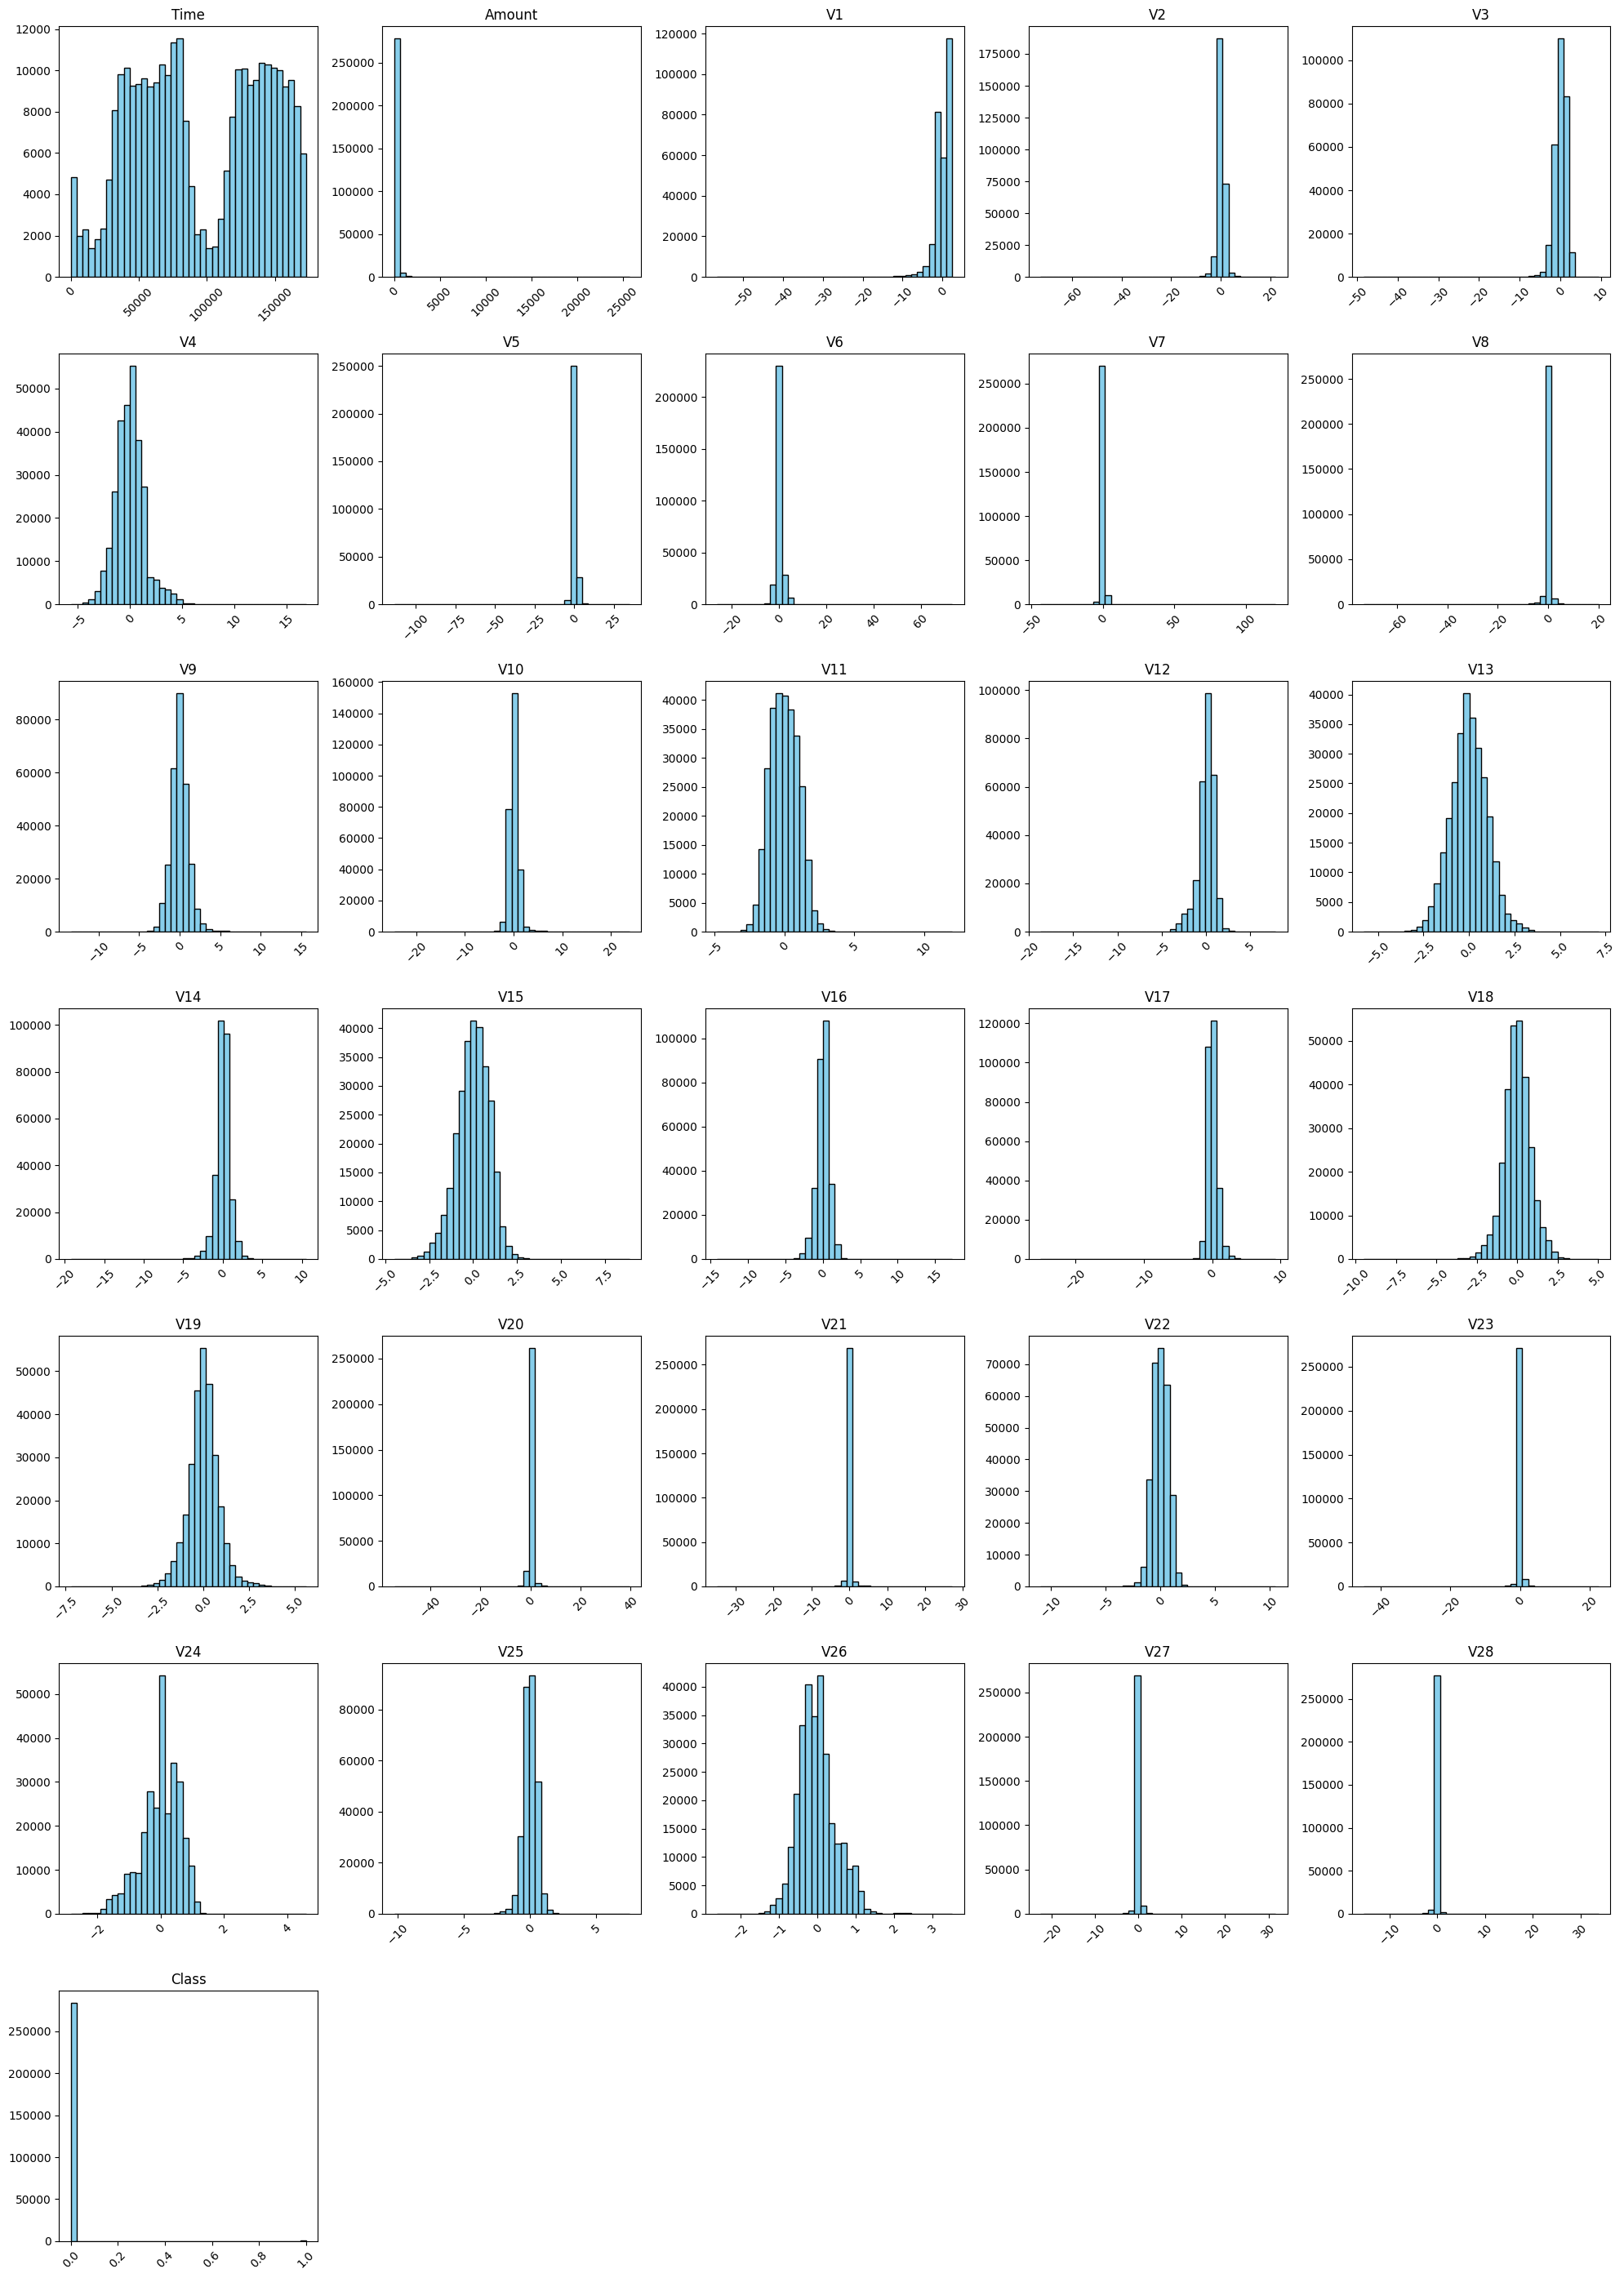

In [ ]:
display(Markdown("## Statistical Summary of Features\nProvides count, mean, standard deviation, min, 25th percentile, 50th percentile (median), 75th percentile, and max for each feature."))
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
print(credit_card_data[feature_cols].describe().T)

n_cols = 5
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    # TODO: Histogram here is a bit different from Kaggle's.
    #       I think the contributing factor is bin size.
    #       Kaggle's histogram has 50 bins (verify!), while mine has 40. Adjusting the bin size may help make it look more similar.
    ax.hist(credit_card_data[col], bins=40, color='skyblue', edgecolor='k')
    ax.set_title(col)
    ax.tick_params(axis='x', labelrotation=45)

for ax in axes[len(feature_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
display(Markdown("## Missing Values Analysis\nCalculates the count and percentage of missing values for each column. Displays only columns with missing values, sorted by count in descending order. If no missing values are detected, a message is printed."))
# missing_summary = credit_card_data.DataFrame({
#     "missing_count": credit_card_data.isnull().sum(),
#     "missing_percent": (credit_card_data.isnull().sum() / len(df)) * 100
# })
# missing_summary.sort_values("missing_count", ascending=False)

missing_counts = credit_card_data.isnull().sum()
missing_percent = 100 * missing_counts / len(credit_card_data)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_report = missing_report[missing_report["missing_count"] > 0].sort_values(
    by="missing_count", ascending=False
)

if missing_report.empty:
    print("No missing values detected in any column.")
else:
    display(missing_report)

## Missing Values Analysis
Calculates the count and percentage of missing values for each column. Displays only columns with missing values, sorted by count in descending order. If no missing values are detected, a message is printed.

No missing values detected in any column.


In [5]:
display(Markdown("## Duplicate Rows Analysis\nCalculates the number and percentage of duplicate rows in the dataset."))
duplicate_count = credit_card_data.duplicated().sum()
duplicate_percent = duplicate_count / len(credit_card_data) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percent)
# TODO: Add visualization for duplicate rows if needed
#      Remove duplicates if necessary and analyze the impact on the dataset.

## Duplicate Rows Analysis
Calculates the number and percentage of duplicate rows in the dataset.

Duplicate rows: 1081
Duplicate percentage: 0.379555277784605


# Class Imbalance Analysis
To highlight and analyze class imbalance in a credit card fraud dataset, we need to inspect both the absolute counts and the relative proportions of each class.

# Description of next section
Below is the complete, production-grade Python code to analyze class imbalance, compute descriptive statistics, and generate a dual-perspective visualization (Linear vs. Logarithmic scales) to clearly illustrate the disparity.

## Why the Dual-Plot Approach is Essential
* Linear Scale Plot: This plot provides an honest depiction of what a machine learning model encounters. The fraudulent class is practically invisible on a standard linear scale, revealing why standard metrics like Accuracy will be misleading. (A naive model predicting everything as class $0$ would achieve an accuracy of $99.83\%$, yet miss $100\%$ of actual frauds).
* Logarithmic Scale Plot: By compressing the y-axis logarithmically ($10^0, 10^1, 10^2$, etc.), the height of the minority class bar becomes visible and readable. This layout enables stakeholders to quickly understand exactly how many anomalous entries are present without losing sight of the overall data scale.



## Class Imbalance Analysis

,count,percent
Class,,
0,284315,99.827251
1,492,0.172749


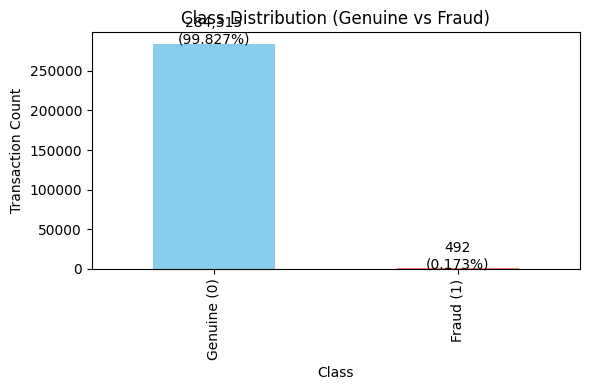

In [6]:
display(Markdown("## Class Imbalance Analysis"))

class_counts = credit_card_data["Class"].value_counts().sort_index()
class_percent = 100 * class_counts / len(credit_card_data)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent
})

display(class_distribution)

fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind="bar", color=["skyblue", "salmon"], ax=ax)
ax.set_title("Class Distribution (Genuine vs Fraud)")
ax.set_xlabel("Class")
ax.set_ylabel("Transaction Count")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Genuine (0)", "Fraud (1)"])

for i, count in enumerate(class_counts):
    ax.text(i, count + len(credit_card_data) * 0.0015,
            f"{count:,}\n({class_percent.iloc[i]:.3f}%)",
            ha="center")

plt.tight_layout()
plt.show()

## Class Imbalance Analysis with Linear and Log Scales

,count,percent
Class,,
0,284315,99.827251
1,492,0.172749


Imbalance ratio (genuine:fraud) = 577.88 to 1


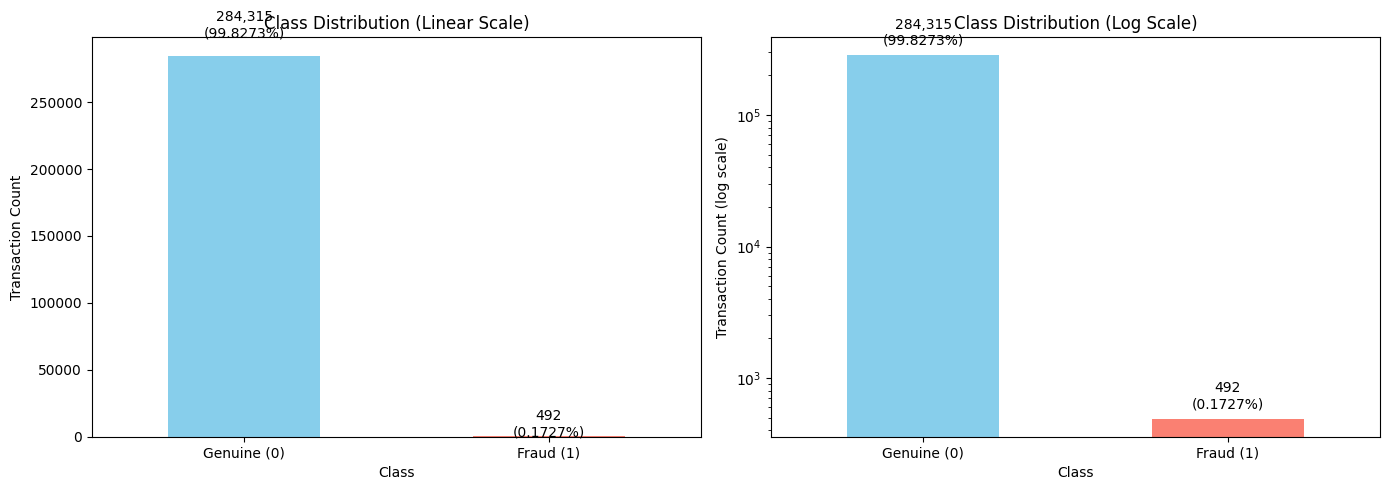

In [7]:
display(Markdown("## Class Imbalance Analysis with Linear and Log Scales"))

class_counts = credit_card_data["Class"].value_counts().sort_index()
class_percent = 100 * class_counts / len(credit_card_data)
imbalance_ratio = class_counts.iloc[0] / class_counts.iloc[1]

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent
})

display(class_distribution)

print(f"Imbalance ratio (genuine:fraud) = {imbalance_ratio:.2f} to 1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(
    kind="bar",
    color=["skyblue", "salmon"],
    ax=axes[0],
    legend=False
)
axes[0].set_title("Class Distribution (Linear Scale)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Transaction Count")
axes[0].set_xticklabels(["Genuine (0)", "Fraud (1)"], rotation=0)

class_counts.plot(
    kind="bar",
    color=["skyblue", "salmon"],
    ax=axes[1],
    legend=False
)
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Transaction Count (log scale)")
axes[1].set_xticklabels(["Genuine (0)", "Fraud (1)"], rotation=0)

for ax in axes:
    for i, count in enumerate(class_counts):
        ax.text(
            i,
            count * (1.05 if ax is axes[0] else 1.2),
            f"{count:,}\n({class_percent.iloc[i]:.4f}%)",
            ha="center"
        )

plt.tight_layout()
plt.show()

## Feature Correlation Matrix

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
Time,1.000000,-0.010596,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,3.061663e-02,-2.476894e-01,1.243481e-01,-6.590202e-02,-9.875682e-02,-1.834533e-01,1.190287e-02,-7.329721e-02,9.043813e-02,2.897530e-02,-5.086602e-02,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.012323
Amount,-0.010596,1.000000,-2.277087e-01,-5.314089e-01,-2.108805e-01,9.873167e-02,-3.863563e-01,2.159812e-01,3.973113e-01,-1.030791e-01,-4.424560e-02,-1.015021e-01,1.039770e-04,-9.541802e-03,5.293409e-03,3.375117e-02,-2.985848e-03,-3.909527e-03,7.309042e-03,3.565034e-02,-5.615079e-02,3.394034e-01,1.059989e-01,-6.480065e-02,-1.126326e-01,5.146217e-03,-4.783686e-02,-3.208037e-03,2.882546e-02,1.025822e-02,0.005632
V1,0.117396,-0.227709,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,7.388135e-17,2.125498e-16,2.053457e-16,-2.425603e-17,-5.020280e-16,3.547782e-16,7.212815e-17,-3.879840e-16,3.230206e-17,1.502024e-16,4.654551e-16,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.101347
V2,-0.010593,-0.531409,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,-3.991394e-16,1.975426e-16,-9.568710e-17,6.295388e-16,-1.730566e-16,-4.995814e-17,1.177316e-17,-2.685296e-16,3.284605e-16,-7.118719e-18,2.506675e-16,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,0.091289
V3,-0.419618,-0.210880,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,1.156587e-15,1.576830e-15,6.310231e-16,2.807652e-16,4.739859e-16,9.068793e-16,8.299445e-16,7.614712e-16,1.509897e-16,3.463522e-16,-9.316409e-16,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.192961
V4,-0.105260,0.098732,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,2.232685e-16,3.459380e-16,-5.625518e-16,1.303306e-16,2.282280e-16,1.377649e-16,-9.614528e-16,-2.699612e-16,-5.103644e-16,-3.980557e-16,-1.857247e-16,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.133447
V5,0.173072,-0.386356,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,-5.202306e-16,7.203963e-16,7.412552e-16,5.886991e-16,6.565143e-16,-8.720275e-16,2.246261e-15,1.281914e-16,5.308590e-16,-1.450421e-16,-3.554057e-16,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.094974
V6,-0.063016,0.215981,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,5.932243e-17,1.980503e-15,2.375468e-16,-1.211182e-16,2.621312e-16,-1.531188e-15,2.623672e-18,2.015618e-16,1.223814e-16,-1.865597e-16,-1.858755e-16,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,-0.043643
V7,0.084714,0.397311,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,-7.492834e-17,1.425248e-16,-3.536655e-18,1.266462e-17,2.607772e-16,-1.690540e-16,5.869302e-17,2.177192e-16,7.604126e-17,-1.881008e-16,9.379684e-16,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,-0.187257
V8,-0.036949,-0.103079,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,-2.801370e-16,2.487043e-16,1.839891e-16,-2.921856e-

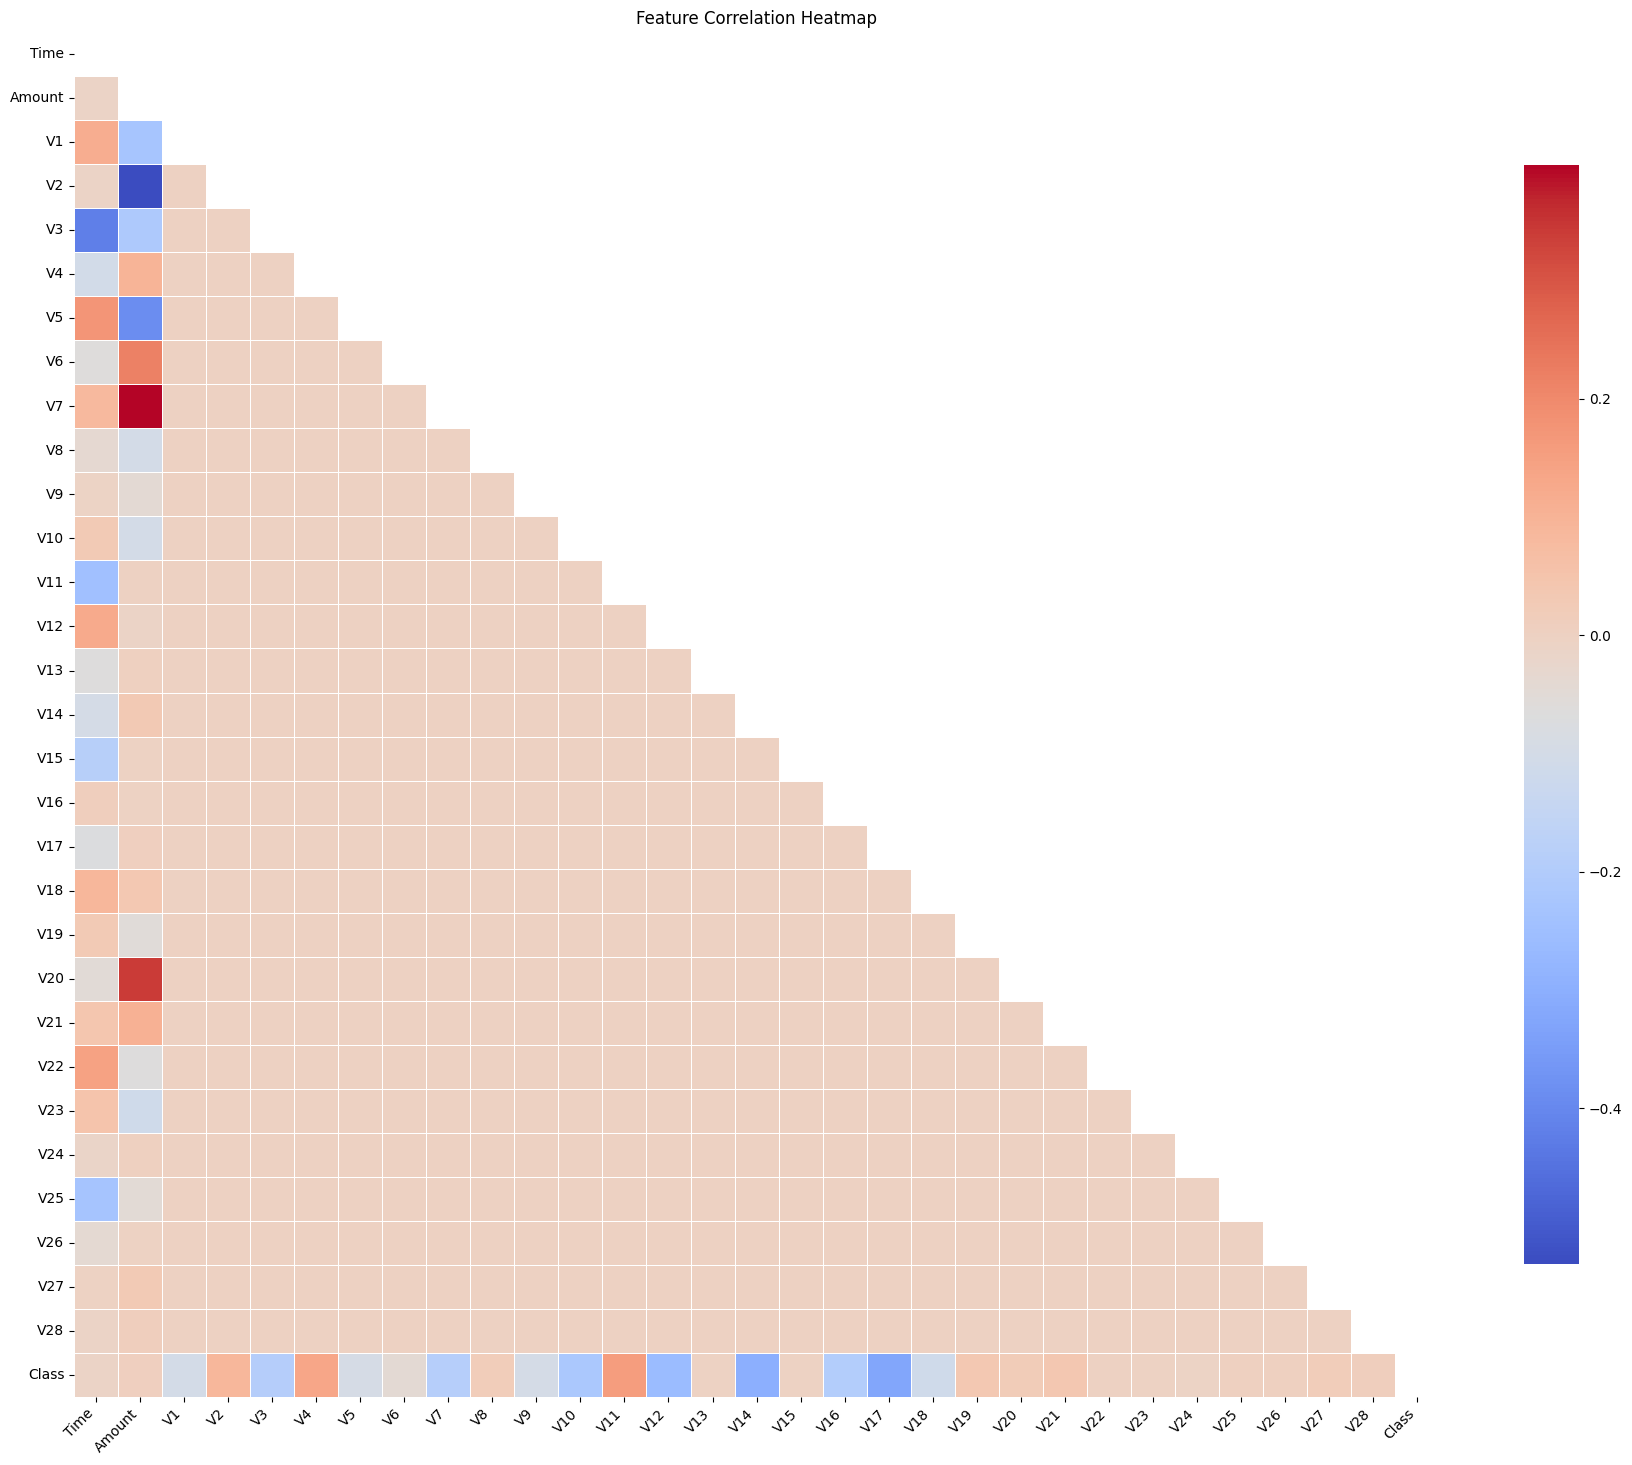

In [8]:
import seaborn as sns

display(Markdown("## Feature Correlation Matrix"))

corr_matrix = credit_card_data[feature_cols].corr()

display(corr_matrix)

plt.figure(figsize=(18, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

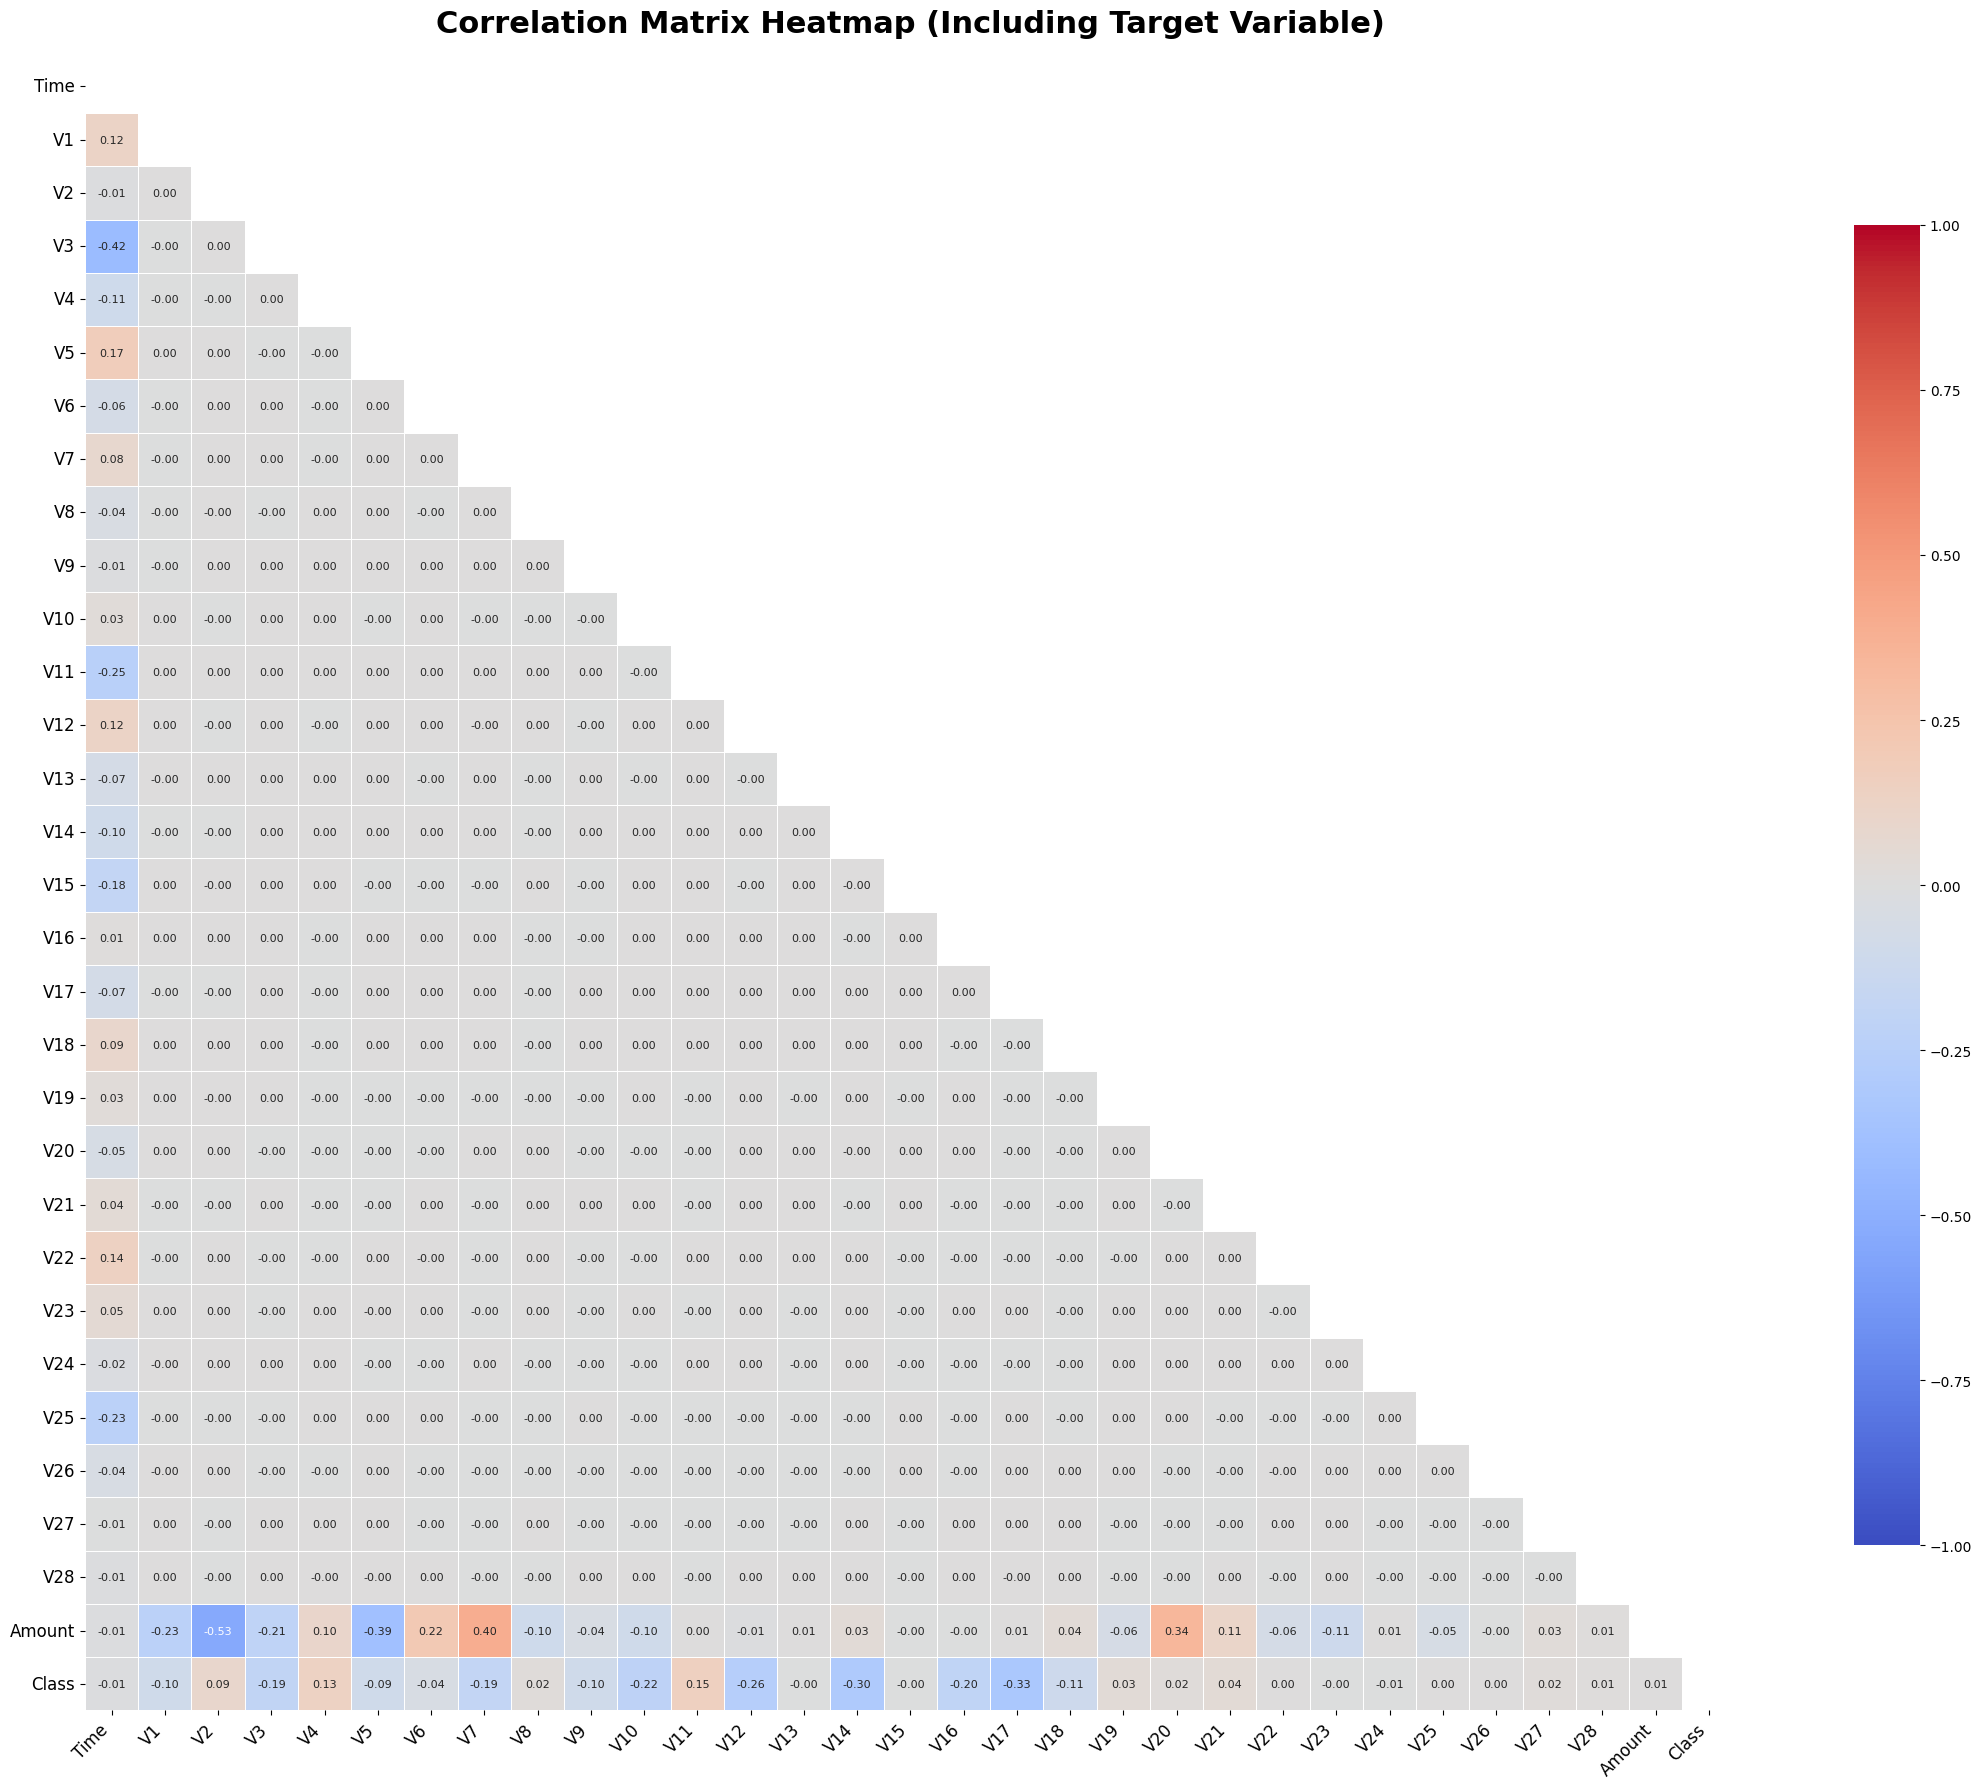

In [13]:
#  2. Compute the correlation matrix
corr_matrix = credit_card_data.corr()

# 3. Create a mask to hide the upper triangle (makes it much easier to read)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Set up the matplotlib figure
plt.figure(figsize=(24, 18))

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm',     # Blue for negative correlation, Red for positive
    vmax=1.0, 
    vmin=-1.0, 
    center=0,            # White represents 0 correlation
    square=True, 
    linewidths=0.5, 
    annot=True,          # Show the correlation numbers
    fmt='.2f',           # Round numbers to 2 decimal places
    annot_kws={"size": 8}, # Text size of the numbers
    cbar_kws={"shrink": 0.8} # Scale down the color bar
)

plt.title('Correlation Matrix Heatmap (Including Target Variable)', fontsize=22, fontweight='bold', pad=20)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

When you look at the heatmap, pay close attention to the following areas:
* The $V$ Features Grid (The "Sea of White"): You will notice that the intersections between $V_1$ through $V_{28}$ are all 0.00. This confirms they are perfect PCA components with zero multicollinearity. This is fantastic news for Logistic Regression.
* The Class Column (The Bottom/Right Edge): This shows how features linearly correlate with fraud.
   * Look for strong negative correlations (deep blue, like $V_{14}$, $V_{17}$, and $V_{12}$). As these values go down, the probability of fraud goes up.
   * Look for strong positive correlations (deep red, like $V_4$ and $V_{11}$). As these values go up, fraud probability goes up.
* The Amount and Time rows: Look closely at where Amount and Time intersect with the $V$ features. Unlike the $V$ features with each other, Amount and Time will show some correlation with certain $V$ components. If any correlation is exceptionally high (e.g., above 0.70), it's a sign of potential multicollinearity, though usually, this dataset behaves well here.

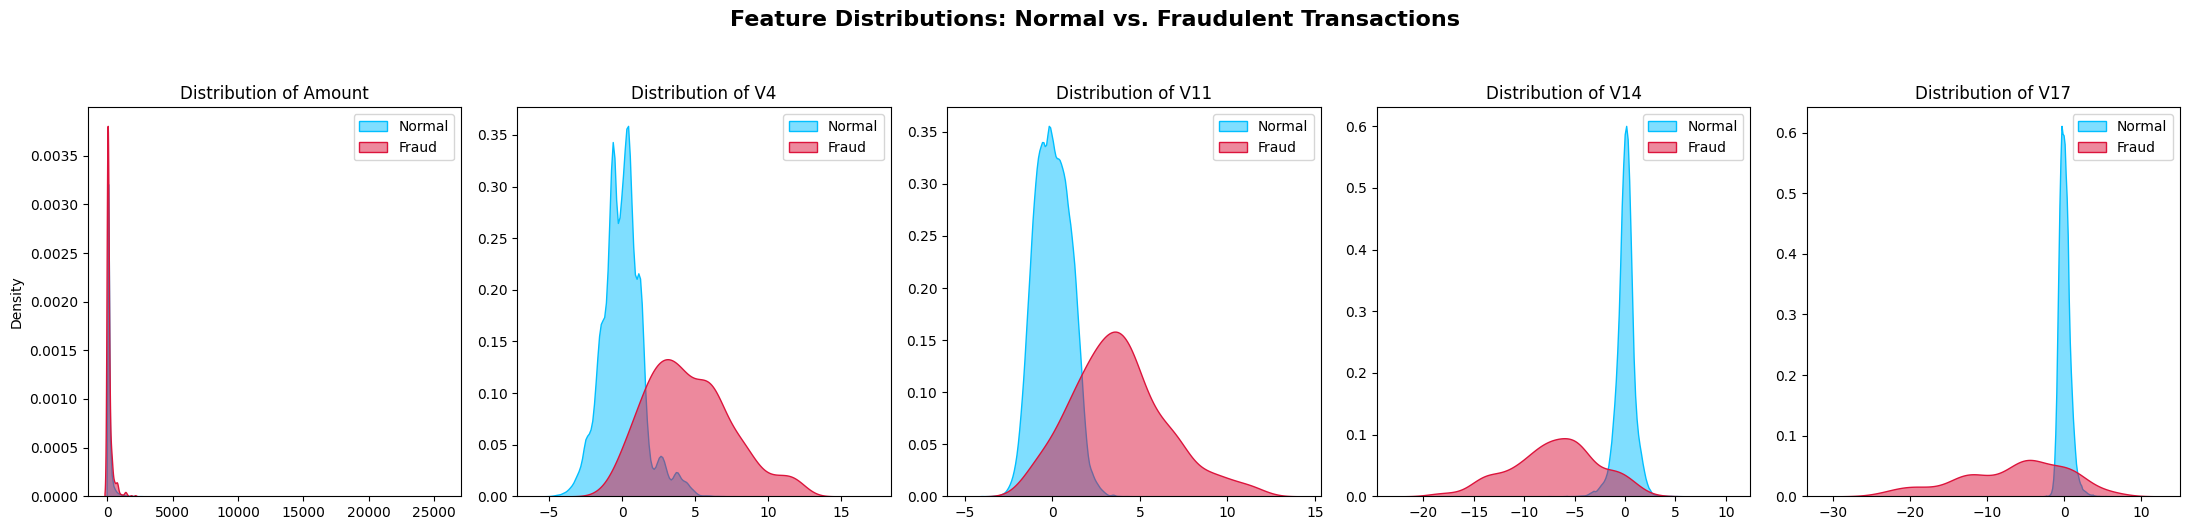

In [9]:
# 2. Separate the classes for easier plotting
normal = credit_card_data[credit_card_data['Class'] == 0]
fraud = credit_card_data[credit_card_data['Class'] == 1]

# 3. Select a mix of features to investigate
# We'll look at 'Amount' (raw) and a few V-features to see the difference
features_to_plot = ['Amount', 'V4', 'V11', 'V14', 'V17'] 

# 4. Set up the matplotlib grid
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(22, 5))
fig.suptitle('Feature Distributions: Normal vs. Fraudulent Transactions', fontsize=16, fontweight='bold', y=1.05)

# 5. Loop through features and plot
for i, col in enumerate(features_to_plot):
    # Plot Normal transactions
    sns.kdeplot(normal[col], ax=axes[i], label='Normal', color='deepskyblue', fill=True, alpha=0.5)
    # Plot Fraudulent transactions
    sns.kdeplot(fraud[col], ax=axes[i], label='Fraud', color='crimson', fill=True, alpha=0.5)
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density' if i == 0 else '') # Only show Y-axis label on the first plot
    axes[i].legend()

plt.tight_layout()
plt.show()

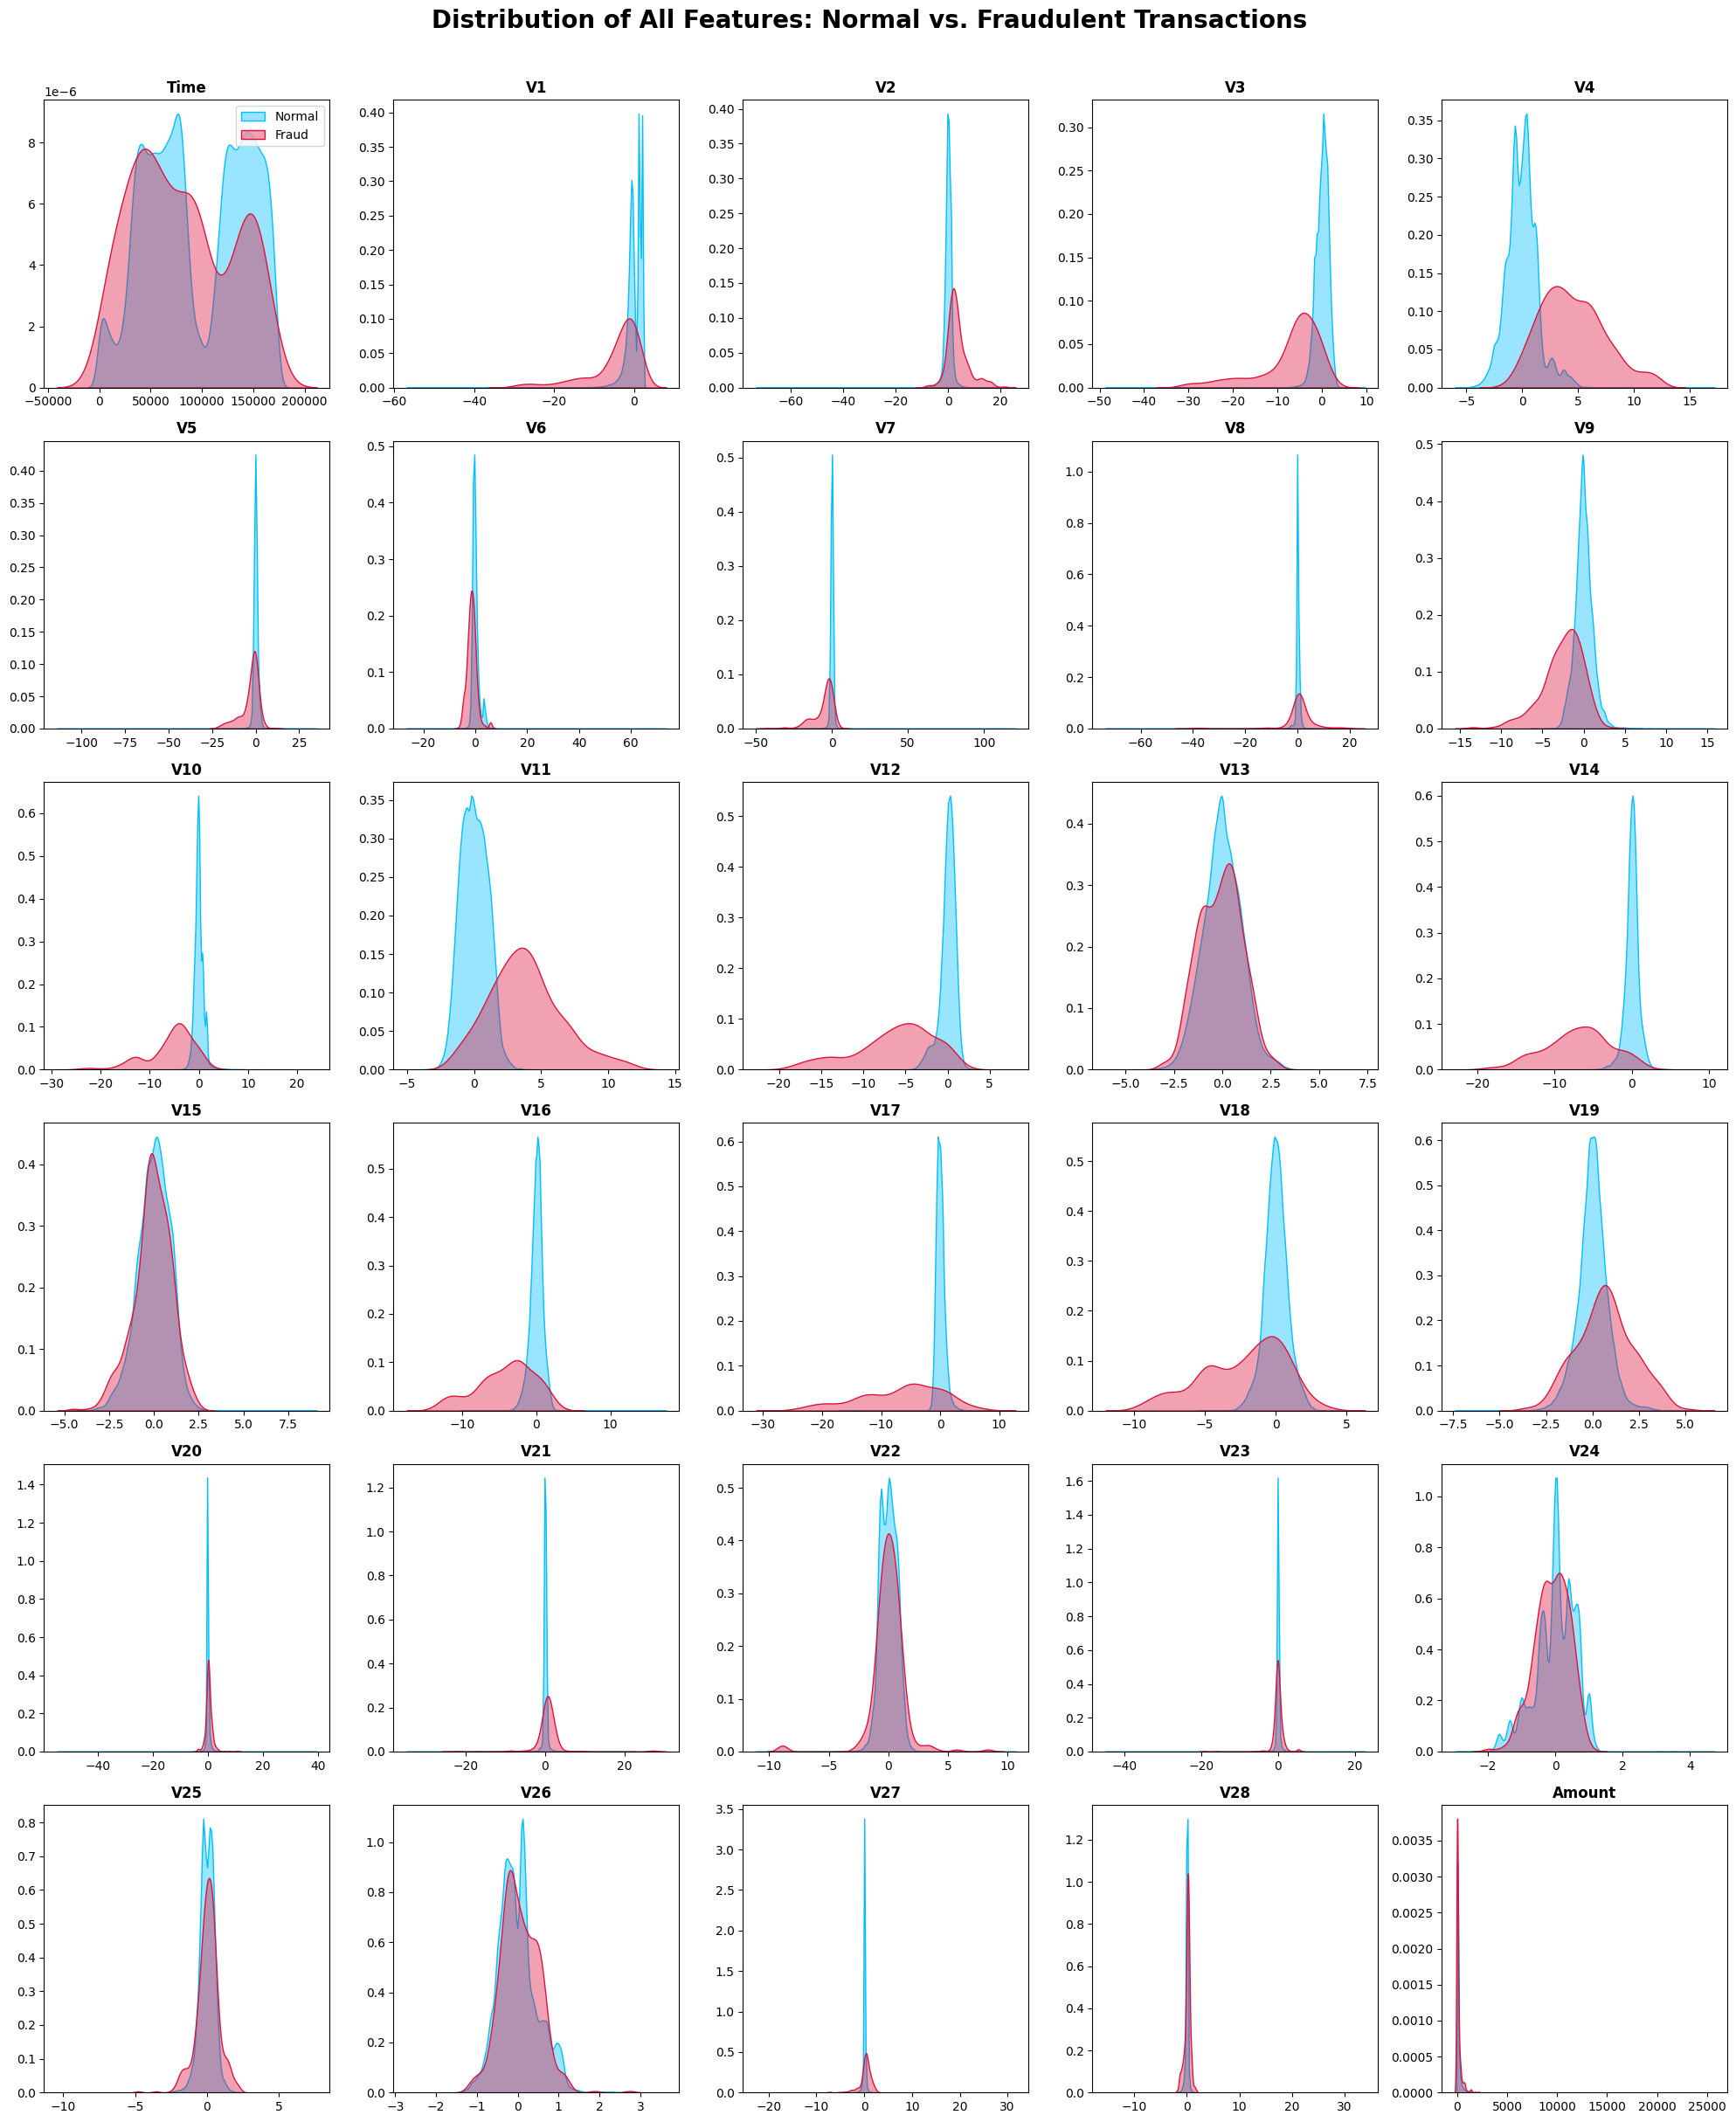

In [10]:
import math
# To plot all 30 features ($V_1$ through $V_{28}$, plus Time and Amount), 
# we need to dynamically generate a grid of subplots. A $6 \times 5$ grid fits all 30 features perfectly.
# Because it is rendering 30 distinct kernel density plots over nearly 285,000 rows, this cell might take 10 to 20 seconds to run. 
# Don't worry if your notebook kernel shows [*] for a brief moment!

# 2. Separate the classes
normal = credit_card_data[credit_card_data['Class'] == 0]
fraud = credit_card_data[credit_card_data['Class'] == 1]

# 3. Get all features dynamically (excluding 'Class')
features = [col for col in credit_card_data.columns if col != 'Class']

# 4. Set up a grid (6 rows, 5 columns = 30 total plots)
cols_per_row = 5
rows = math.ceil(len(features) / cols_per_row)

fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(20, 4 * rows))
fig.suptitle('Distribution of All Features: Normal vs. Fraudulent Transactions', fontsize=20, fontweight='bold', y=1.01)

# Flatten axes array for easy looping
axes = axes.flatten()

# 5. Loop through all 30 features
for i, col in enumerate(features):
    # Plot Normal transactions
    sns.kdeplot(normal[col], ax=axes[i], label='Normal', color='deepskyblue', fill=True, alpha=0.4)
    # Plot Fraudulent transactions
    sns.kdeplot(fraud[col], ax=axes[i], label='Fraud', color='crimson', fill=True, alpha=0.4)
    
    # Customizations per subplot
    axes[i].set_title(f'{col}', fontsize=12, fontweight='semibold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    # Only show the legend on the very first subplot to keep things clean
    if i == 0:
        axes[i].legend(loc='upper right')
    else:
        axes[i].get_legend().remove() if axes[i].get_legend() else None

# Hide any unused subplots (if your dataset layout changes, though 30 fits perfectly here)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* For Amount: You will see a massive spike near zero for both, but the scales might be wildly different due to heavy skewness. This visually confirms why you need to scale this feature.
* For the $V$ features: Look closely at features like V14 and V17. You will notice that the blue (Normal) and red (Fraud) curves barely overlap. These features have high separability, meaning your Logistic Regression model will easily draw a boundary line to catch fraud using them.
* The Opposite: If you were to plot a feature like $V_{22}$, you'd see the red and blue curves sit almost perfectly on top of each other. That means that specific feature provides almost no predictive power for fraud.
* The "Zero-Separation" Features: Look at $V_{14}$, $V_{12}$, $V_{11}$, $V_4$, and $V_{17}$. The fraud (red) distributions are completely shifted away from the normal (blue) distributions. These are going to be your Logistic Regression model's favorite features.
* The "Noise" Features: Look at $V_{22}$, $V_{23}$, or $V_{25}$. The red and blue curves sit almost perfectly on top of each other. A linear model will likely assign coefficients close to 0 to these, as they don't help differentiate fraud.
* The Scale of Time and Amount: Look at the X-axis numbers for Time (ranges up to 175,000+) and Amount (ranges up to 25,000+) compared to the $V$ features (which mostly range between -10 and 10). This visually proves that without scaling Time and Amount, your model will struggle.